In [20]:
import numpy as np 
import pandas as pd
import scipy.stats as stats 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv('Walmart_Sales.csv')

In [3]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
df.Unemployment.shape

(6435,)

In [53]:
X_train , X_test , y_train , y_test = train_test_split(df.drop(columns = ['Date' , 'Unemployment' ]) , df['Unemployment'] , random_state = 48 , test_size= 0.3 )

In [17]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


<!-- Training without power Transformation  -->

In [19]:
from sklearn.linear_model import LinearRegression 
lR = LinearRegression()
lR.fit(X_train , y_train)
y_pred_ = lR.predict(X_test)
r2_score(y_test , y_pred_)


0.16661549260170083

Cross_Variance_Score

In [22]:
np.mean(cross_val_score(lR  , df.drop(columns = ['Date' , 'Unemployment' ]) , df['Unemployment'] , scoring='r2'))


np.float64(-0.37451961534423217)

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


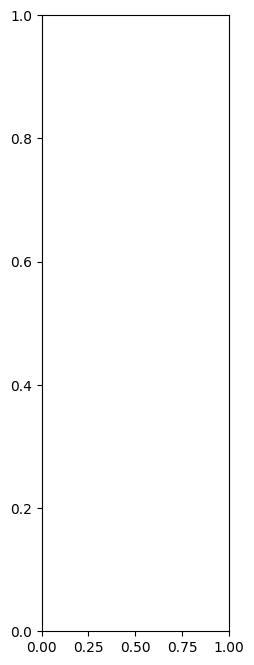

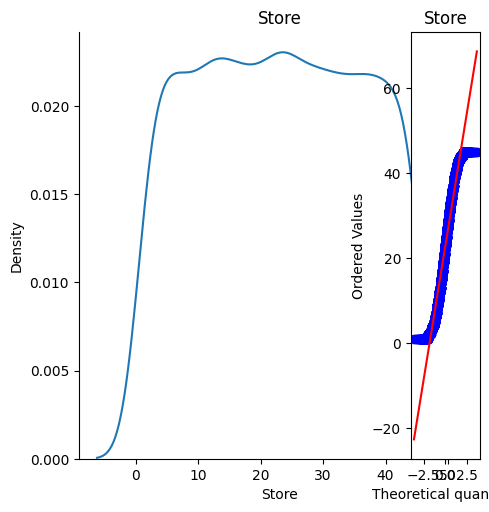

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


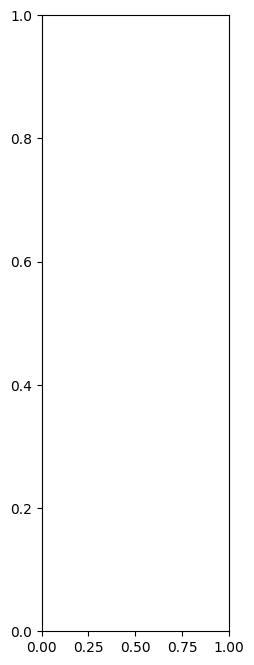

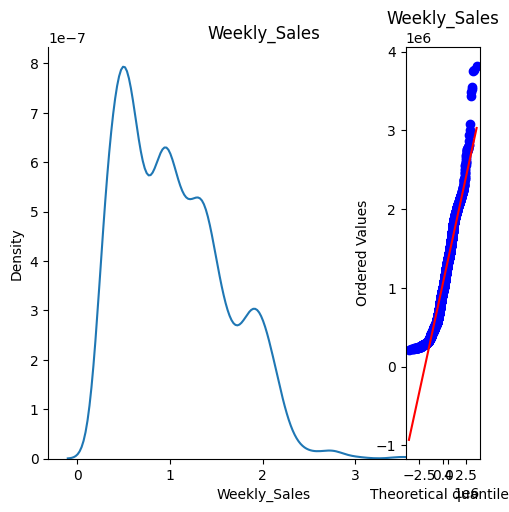

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


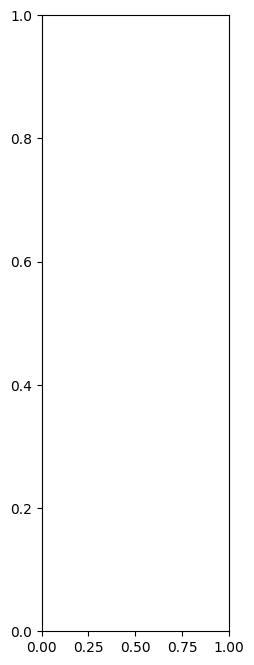

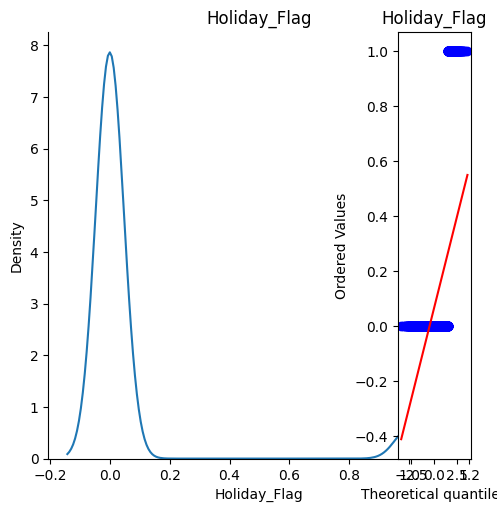

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


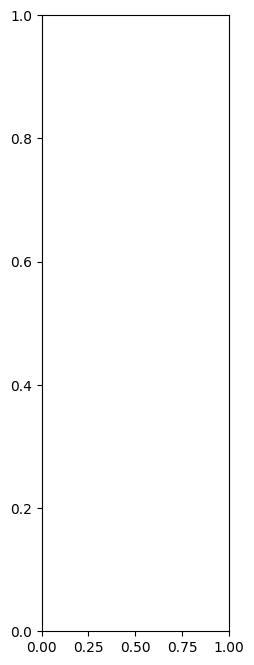

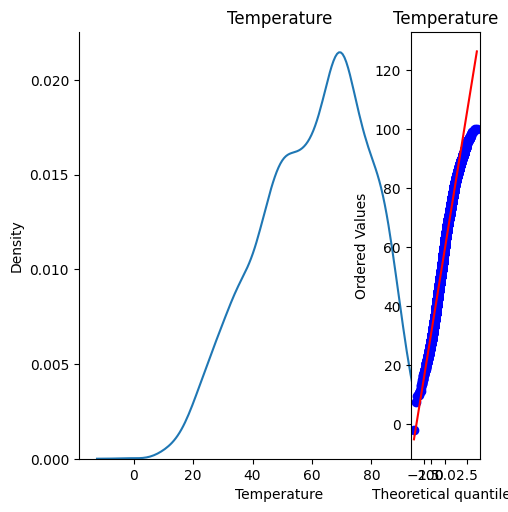

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


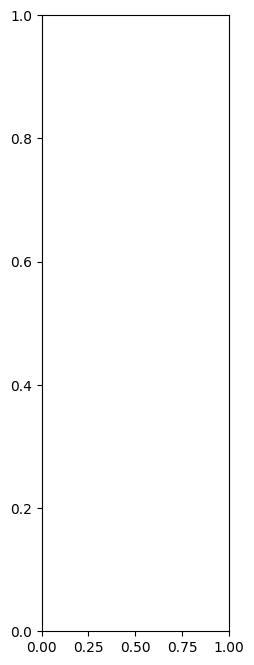

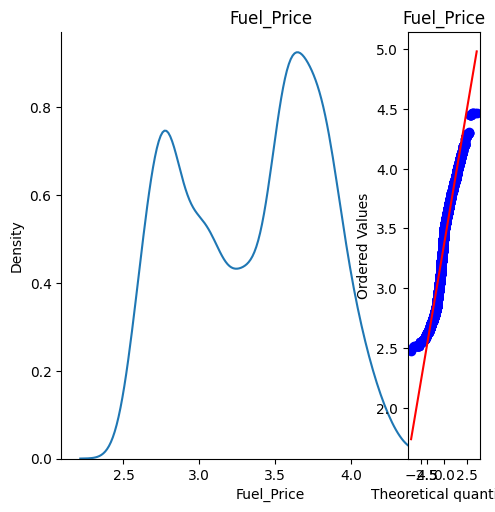

C:\Users\gulshan\AppData\Local\Temp\ipykernel_18636\2145637884.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')


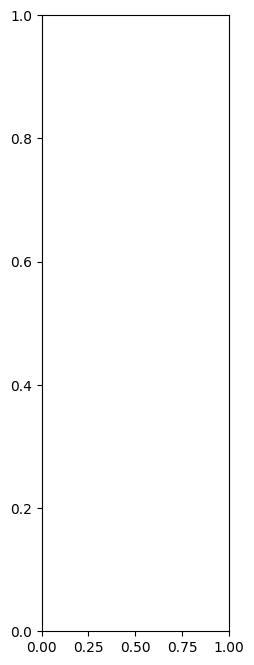

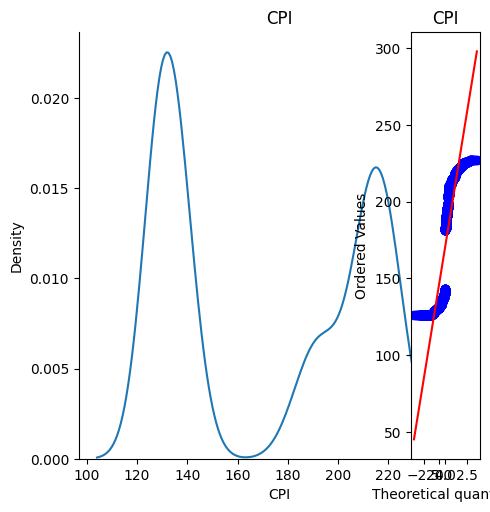

In [32]:
for col in X_train.columns:
    plt.figure(figsize=(14,8))
    plt.subplot(151)
    sns.displot(X_train[col] , kind  =  "kde" , palette = 'winter')
    plt.title(col)

    plt.subplot(155)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

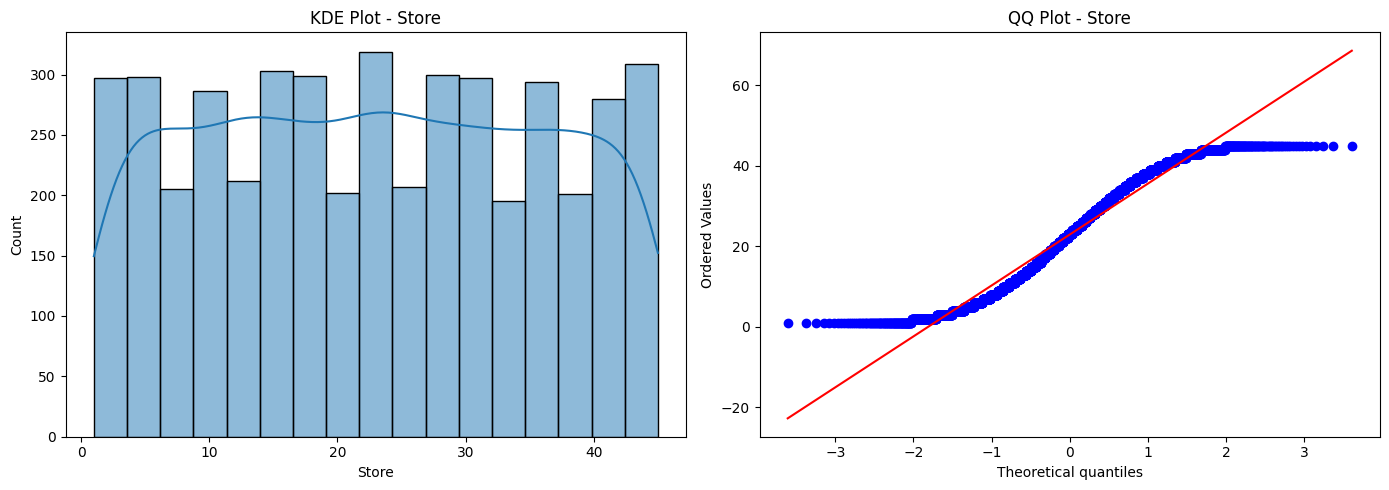

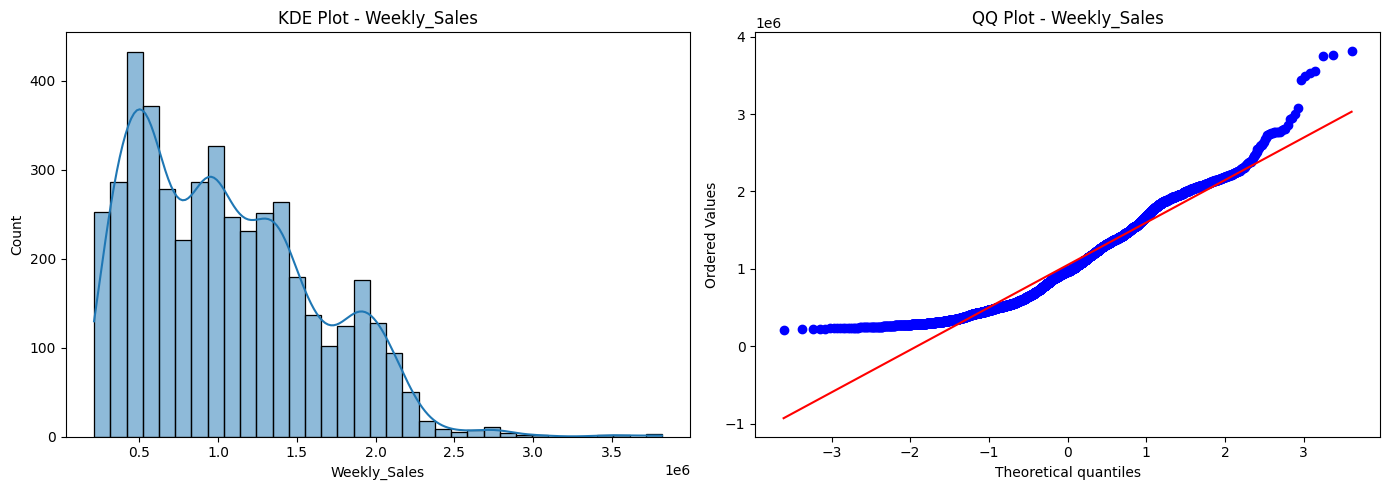

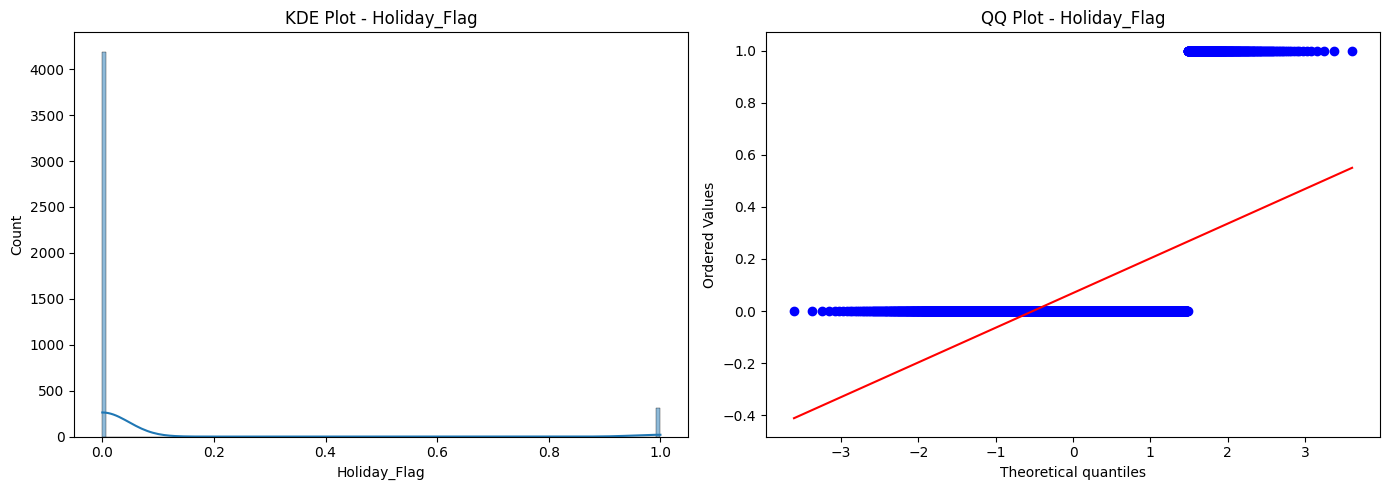

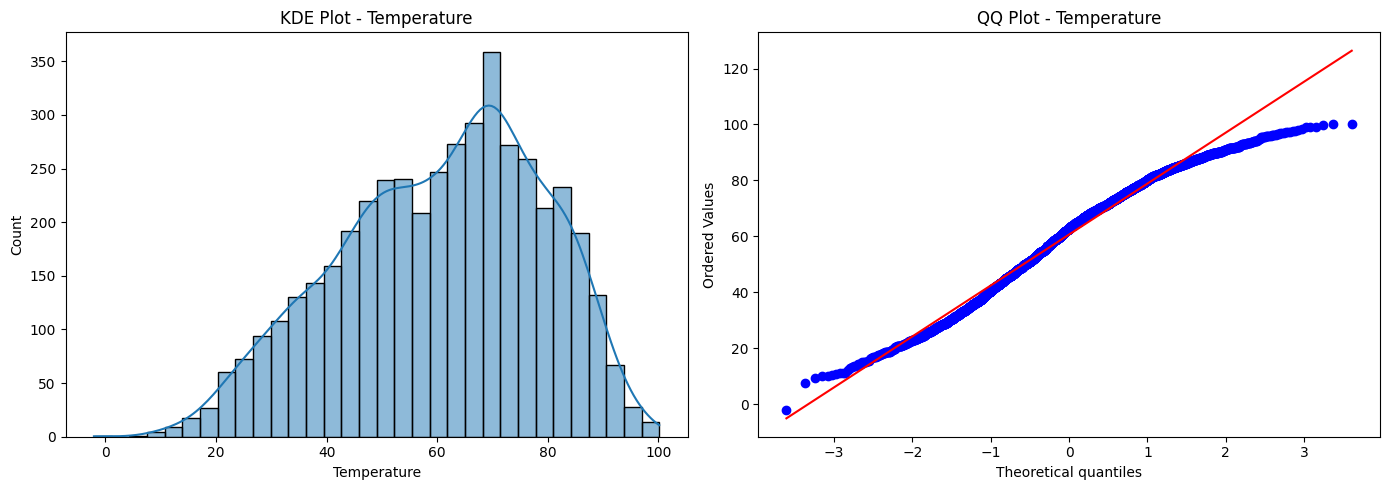

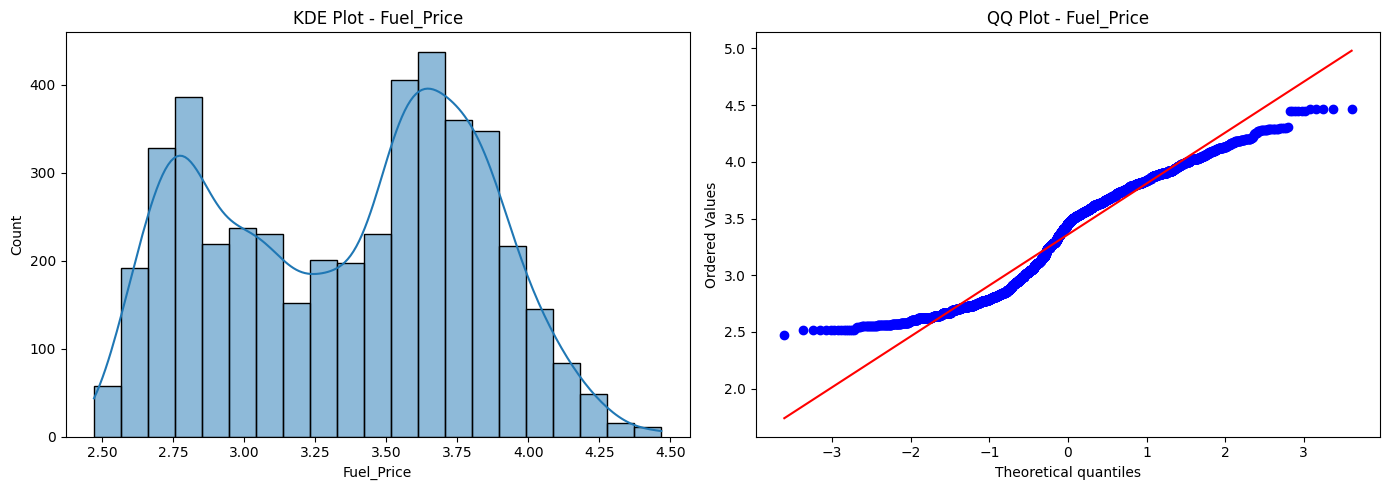

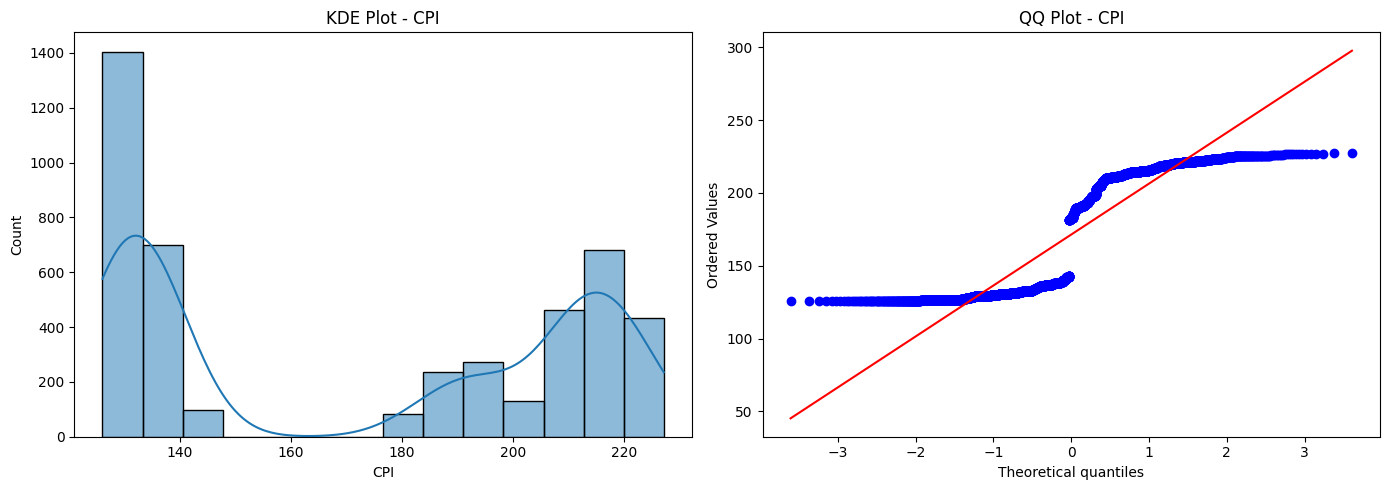

In [34]:
for col in X_train.columns:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    # sns.kdeplot(X_train[col], fill=True)
    sns.histplot(X_train[col] , kde = True)
    plt.title(f"KDE Plot - {col}")

    plt.subplot(1, 2, 2)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(f"QQ Plot - {col}")

    plt.tight_layout()
    plt.show()

In [35]:
from sklearn.preprocessing import PowerTransformer

In [39]:
df.Temperature.skew()

np.float64(-0.3367676011075799)

In [40]:
df.Holiday_Flag.skew()

np.float64(3.3734986714578485)

In [41]:
df.CPI.skew()

np.float64(0.06349184988549494)

In [50]:
df.shape

(6435, 8)

In [56]:
pT = PowerTransformer()

X_train_transformed = pT.fit_transform(X_train)
X_test_transformed = pT.transform(X_test)




In [48]:
pT.lambdas_.shape

(5,)

In [49]:
X_train.shape

(4504, 6)

In [57]:
pT.lambdas_

array([  0.72676176,   0.27673792, -20.82643564,   1.30470284,
         1.34982317,  -0.0921431 ])

In [52]:
X_train.columns

Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
       'CPI'],
      dtype='str')

In [59]:
dict = {
    'columns' : X_train.columns ,
    'lambdas' : pT.lambdas_
}
dict

{'columns': Index(['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
        'CPI'],
       dtype='str'),
 'lambdas': array([  0.72676176,   0.27673792, -20.82643564,   1.30470284,
          1.34982317,  -0.0921431 ])}

In [60]:
pd.DataFrame(dict , )

,columns,lambdas
0,Store,0.726762
1,Weekly_Sales,0.276738
2,Holiday_Flag,-20.826436
3,Temperature,1.304703
4,Fuel_Price,1.349823
5,CPI,-0.092143


In [63]:
Lr = LinearRegression()
Lr.fit(X_train_transformed , y_train)
y_pred = Lr.predict(X_test_transformed)
print(r2_score(y_test , y_pred))
# cross_val_score(X , y)

0.1648098689417853


In [66]:
cross_val_score(Lr , df.drop(columns = ['Date' , 'Unemployment' ]) , df['Unemployment'] , scoring = 'r2').mean()

np.float64(-0.37451961534423217)